In [1]:
import os
import json
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from tqdm import tqdm

In [2]:
def set_seed(seed= 42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

if torch.cuda.is_available():

    print(torch.cuda.get_device_name(0))

using device: cuda
NVIDIA GeForce RTX 2060


In [6]:
json_path="labels.json"
with open(json_path, "r") as f:
    labels_data=json.load(f)

ingredient_mapping=labels_data["ingredient_mapping"]
labels_dict=labels_data["labels"]

print("ingredients:")
for k, v in ingredient_mapping.items():

    print(k, "-", v)

print("\ntotal images:", len(labels_dict))
num_classes=len(ingredient_mapping)

ingredients:
1 - avocado
2 - bread
3 - carrot
4 - cheese
5 - corn
6 - cucumber
7 - egg_boiled
8 - egg_fried
9 - lettuce
10 - oatmeal_porridge
11 - pasta
12 - potato
13 - sausage_boiled
14 - smoked_salmon_slices
15 - tomato
16 - chicken

total images: 274


In [7]:
transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
class IngredientsDataset(Dataset):
    def __init__(
        self,
        image_dir,
        labels_dict,
        transform=None
    ):
        self.image_dir=image_dir
        self.labels_dict=labels_dict
        self.transform=transform
        self.image_names=list(labels_dict.keys())
    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        image_path = os.path.join(
            self.image_dir,
            image_name
        )
        image=Image.open(image_path).convert("RGB")
        if self.transform:
            image=self.transform(image)

        #multi-hot vector
        label_vector=torch.zeros(num_classes)
        ingredient_ids=self.labels_dict[image_name]
        for ingredient_id in ingredient_ids:
            label_vector[ingredient_id-1]=1.0
        return image, label_vector

In [13]:
image_dir = "data/mixed"
full_dataset = IngredientsDataset(
    image_dir=image_dir,
    labels_dict=labels_dict,
    transform=transform
)

In [14]:
indices = list(range(len(full_dataset)))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)
print("train:", len(train_idx))
print("val:", len(val_idx))
print("test:", len(test_idx))

train: 191
val: 41
test: 42


In [15]:
from torch.utils.data import Subset
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
test_dataset = Subset(full_dataset, test_idx)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16,shuffle=False)


In [16]:
model=models.resnet18(weights="DEFAULT")
#change last layer, because there are 16 classes
in_features=model.fc.in_features
model.fc=nn.Linear(
    in_features,
    num_classes
)
model=model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
import torch.optim as optim
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [18]:
def train_one_epoch(model, loader):

    model.train()
    total_loss=0
    for images, labels in loader:
        images=images.to(device)
        labels=labels.to(device)
        optimizer.zero_grad()
        outputs =model(images)
        loss=criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()

    avg_loss=total_loss/len(loader)
    return avg_loss

In [20]:
def validate(model, loader):
    model.eval()
    total_loss=0
    with torch.no_grad():
        for images, labels in loader:
            images=images.to(device)
            labels=labels.to(device)
            outputs=model(images)
            loss=criterion(outputs, labels)
            total_loss+=loss.item()

    avg_loss=total_loss/len(loader)
    return avg_loss

In [21]:
num_epochs=10
train_losses=[]
val_losses=[]
for epoch in range(num_epochs):
    train_loss= train_one_epoch(model, train_loader)

    val_loss=validate(model, val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")


Epoch 1/10
Train Loss: 0.2844
Val Loss: 1.0398

Epoch 2/10
Train Loss: 0.2280
Val Loss: 0.5131

Epoch 3/10
Train Loss: 0.2089
Val Loss: 0.4331

Epoch 4/10
Train Loss: 0.1681
Val Loss: 0.4767

Epoch 5/10
Train Loss: 0.1462
Val Loss: 0.4214

Epoch 6/10
Train Loss: 0.1369
Val Loss: 0.3944

Epoch 7/10
Train Loss: 0.1123
Val Loss: 0.7083

Epoch 8/10
Train Loss: 0.1041
Val Loss: 0.4398

Epoch 9/10
Train Loss: 0.0998
Val Loss: 0.6418

Epoch 10/10
Train Loss: 0.0772
Val Loss: 0.4002


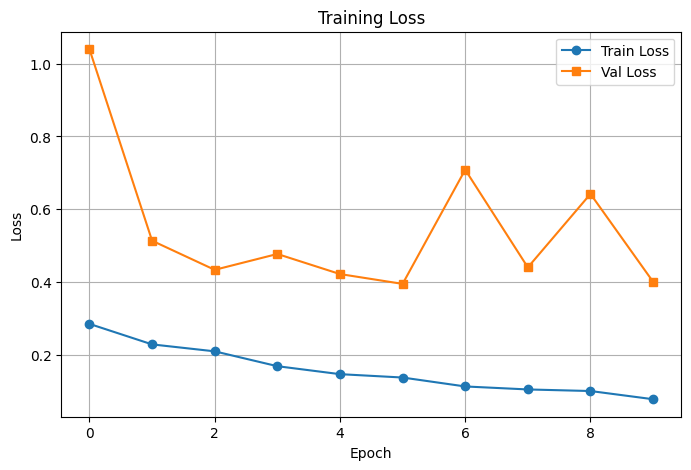

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Val Loss", marker="s")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
torch.save(model.state_dict(), "ingredient_model.pth")

print("saved")

saved
